In [10]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

In [11]:
#%matplotlib inline
auto_plot_style()

In [12]:
def sipm_positions():
    size   = 6
    gap    = 0.2
    n      = 5
    offset = n * (size + gap) / 2.
    xy     = (np.arange(n) + 0.5) * (size + gap) - offset
    return (xy, *np.meshgrid(xy, xy, indexing="ij"))

def extent():
    size   = 6
    gap    = 0.2
    n      = 5
    offset = n * (size + gap) / 2.
    return (-offset, offset) * 2

def npmap(f, it):
    return np.array(list(map(f, it)))

def wire_pos():
    n = 6
    p = 5
    return np.arange(12) * p - (n - 1) * p/2

def wire_limits():
    p = wire_pos()
    return np.append(p - 2.5, p[-1] + 2.5)

empty_df = pd.DataFrame(dict(counts=0), index=pd.Index(np.arange(25), name="sensor_id"))
def image(df):
    df = df.set_index("sensor_id")
    df = pd.concat([df, empty_df])
    df = df.groupby(level=0).sum()
    return pd.DataFrame(dict(image=[df.sort_index().counts.values.reshape(1, 5, 5)]))

def rotate(xy, a):
    c = np.cos(a)
    s = np.sin(a)
    m = np.array([ [c, -s]
                 , [s,  c] ])
    return m.dot(xy)
    
def gate_pos(df, a=np.pi/4):
    xrot, yrot = rotate(df.loc[:, list("xy")].values.T, np.pi/4)
    xi         = np.clip(np.digitize(xrot, wire_limits()) - 1, 0, 6)
    wx         = wire_pos()[xi]
    dx         = xrot - wx
    a          = np.arctan(dx/(df.z - (-5.20)))
    dx         = a/(np.pi/2) * 2.5
    x, y       = rotate(np.stack([wx+dx, yrot], axis=1).T, -np.pi/4)
    return pd.DataFrame(dict(event=df.event, x0=x, y0=y, z0=df.z))

def read_file(filename):
    sensor_hits = pd.read_hdf(filename, "/MC/sensor_hits").loc[lambda df: df.sensor_id < 100]
    sources     = pd.read_hdf(filename, "/MC/sources").drop(columns="e n".split())
    sources     = gate_pos(sources)
    sources     = sources.set_index("event")
    sources.insert(3, "r0", (sources.x0**2 + sources.y0**2)**0.5)
    sensor_hits = sensor_hits.groupby("event sensor_id".split()).count().rename(columns=dict(time="counts")).reset_index()
    images = (sensor_hits.groupby("event")
                         .apply(image, include_groups=False)
                         .reset_index(level=1, drop=True))
    out = pd.concat([sources, images], axis=1)
    out = out[~out.image.isna()]
    return out

def barycenter(df, sipm_x, sipm_y, nsipms):
    img = df.image.values[0][0]
    tot = img.sum().sum()
    xb  = (sipm_x * img).sum().sum() / tot
    yb  = (sipm_y * img).sum().sum() / tot
    return pd.Series(dict(x=xb, y=yb))

In [13]:
path      = Path("/home/gonzalo/data/COLINA/mc/pcolina_dsipms_15mm/")
filenames = sorted(path.glob("*.h5"))
len(filenames)

20

In [14]:
testdf = read_file(filenames[0])
testdf

,x0,y0,z0,r0,image
event,,,,,
0,16.436859,3.484968,-5.177589,16.802242,"[[[2, 0, 4, 7, 3], [5, 2, 6, 3, 6], [4, 7, 7, ..."
1,3.748823,10.269261,-5.190596,10.932127,"[[[2, 7, 5, 4, 7], [3, 3, 5, 6, 7], [3, 5, 8, ..."
2,8.727388,10.083537,-5.177660,13.335854,"[[[3, 2, 3, 13, 3], [3, 4, 3, 6, 6], [4, 5, 3,..."
3,6.606881,11.292135,-5.172573,13.082935,"[[[3, 1, 4, 5, 6], [4, 2, 7, 3, 8], [3, 3, 6, ..."
4,-4.739762,-10.639096,-5.178727,11.647132,"[[[2, 2, 9, 2, 4], [3, 3, 6, 6, 1], [6, 9, 11,..."
...,...,...,...,...,...
49995,12.851382,3.230180,-5.165300,13.251117,"[[[2, 2, 3, 2, 1], [5, 5, 4, 5, 3], [6, 5, 4, ..."
49996,-16.306832,4.855633,-5.199028,17.014404,"[[[8, 5, 13, 10, 14], [2, 7, 6, 7, 7], [7, 8, ..."
49997,-8.256498,8.760052,-5.157411,12.037785,"[[[1, 4, 5, 3, 1], [3, 4, 7, 8, 10], [3, 2, 7,..."


In [94]:
rbins  = np.linspace(  0, 16, 81)
xybins = np.linspace(-16, 16, 81)
drbins = np.linspace(  0, 16, 81)

In [16]:
nsipms    = 5
sipm_pos  = sipm_positions()[0]
sipm_x    = sipm_positions()[1]
sipm_y    = sipm_positions()[2]
extents   = extent()
ticks     = np.arange(-15, 15, 10)

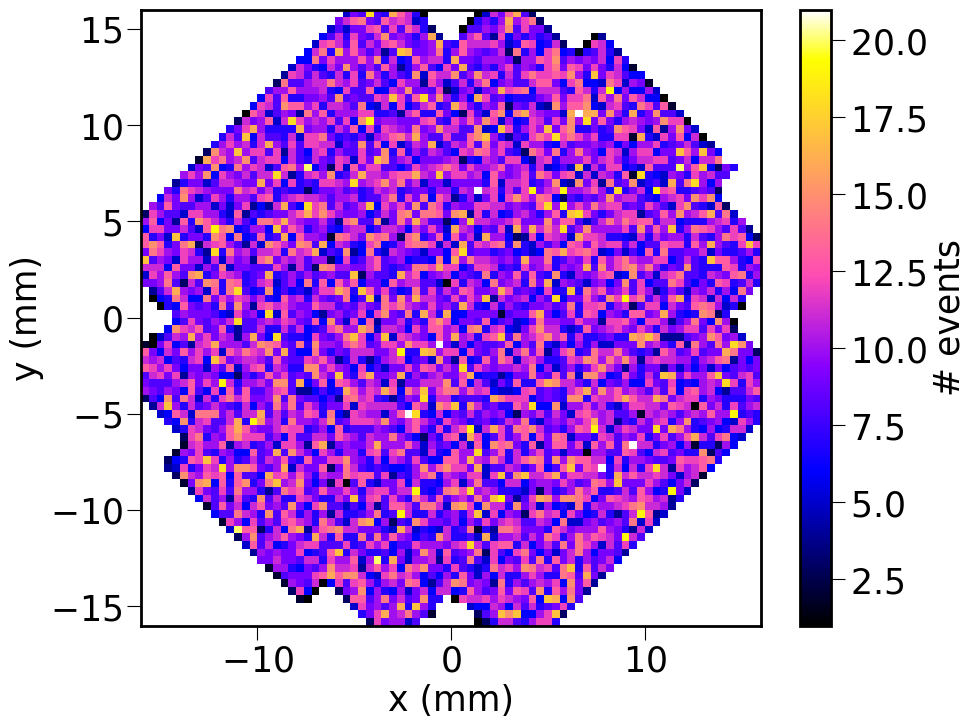

In [17]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

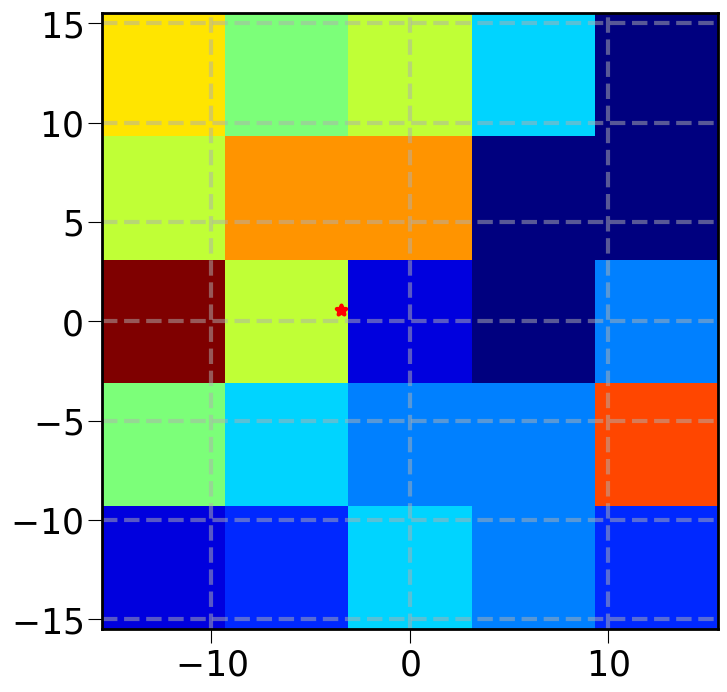

In [18]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extent(), cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.grid()

# Barycenter

In [19]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y, nsipms)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [20]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,1.537600,1.041600,16.436859,3.484968,-5.177589,16.802242,-14.899259,-2.443368,15.098277
1,0.195276,1.513386,3.748823,10.269261,-5.190596,10.932127,-3.553548,-8.755875,9.449500
2,0.745865,1.864662,8.727388,10.083537,-5.177660,13.335854,-7.981523,-8.218875,11.456641
3,-0.574074,3.272222,6.606881,11.292135,-5.172573,13.082935,-7.180955,-8.019913,10.764995
4,1.088550,-0.425954,-4.739762,-10.639096,-5.178727,11.647132,5.828311,10.213141,11.759144
...,...,...,...,...,...,...,...,...,...
49995,2.221667,1.395000,12.851382,3.230180,-5.165300,13.251117,-10.629716,-1.835180,10.786971
49996,-3.693617,0.571631,-16.306832,4.855633,-5.199028,17.014404,12.613215,-4.284001,13.320881
49997,0.258333,2.893333,-8.256498,8.760052,-5.157411,12.037785,8.514831,-5.866719,10.340249


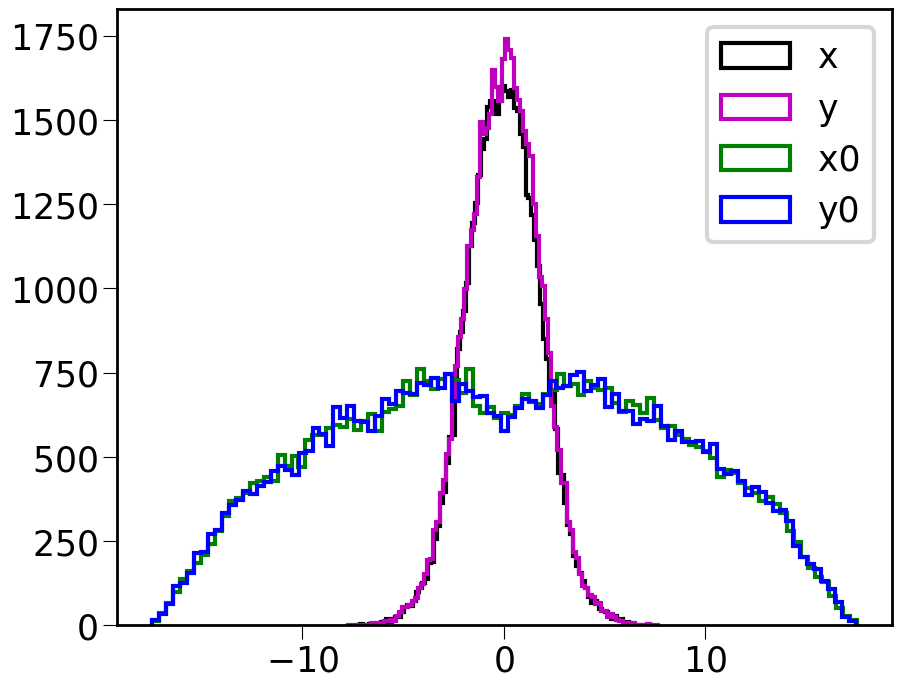

In [21]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

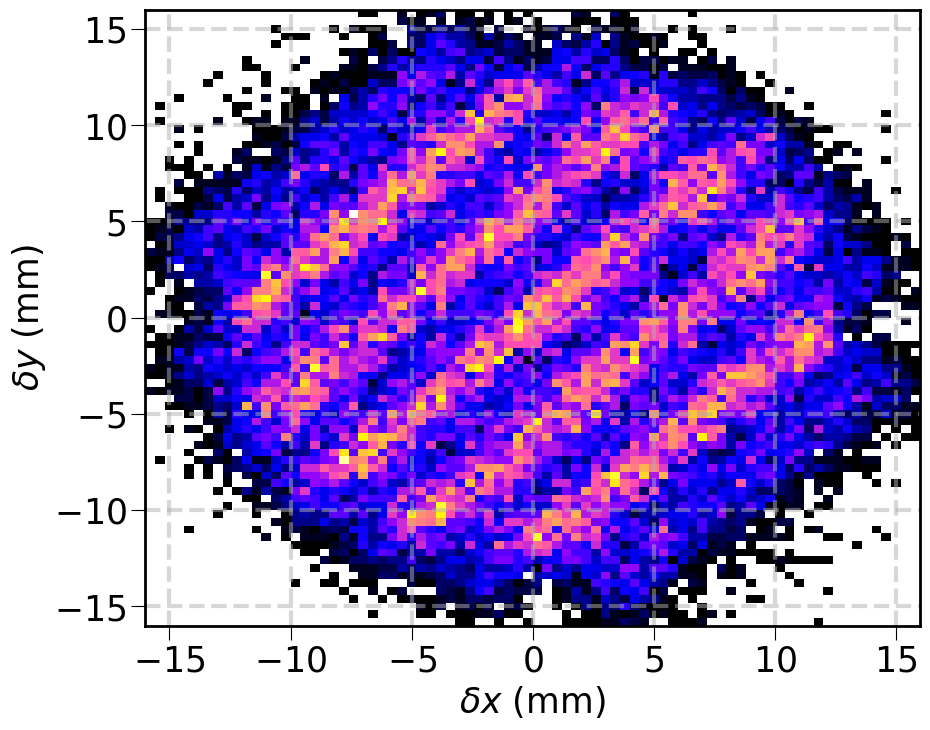

In [22]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

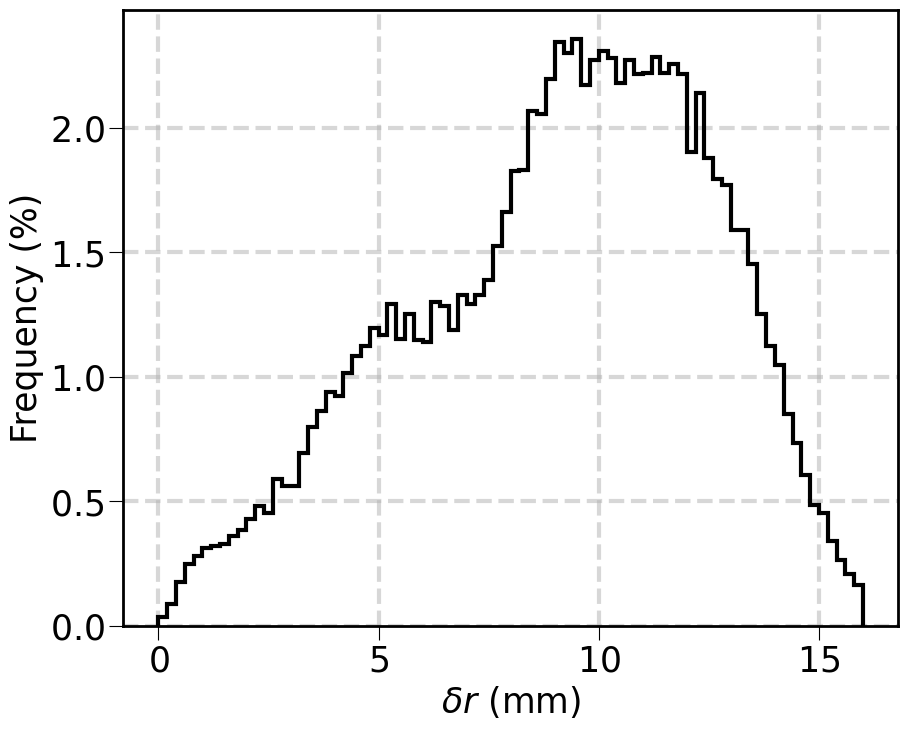

In [23]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

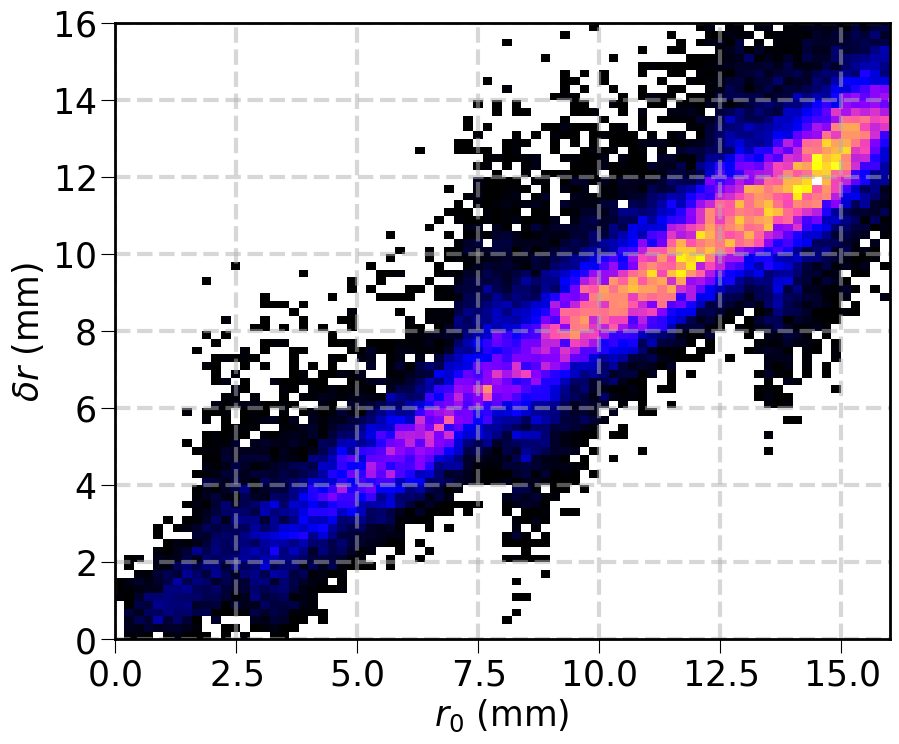

In [24]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

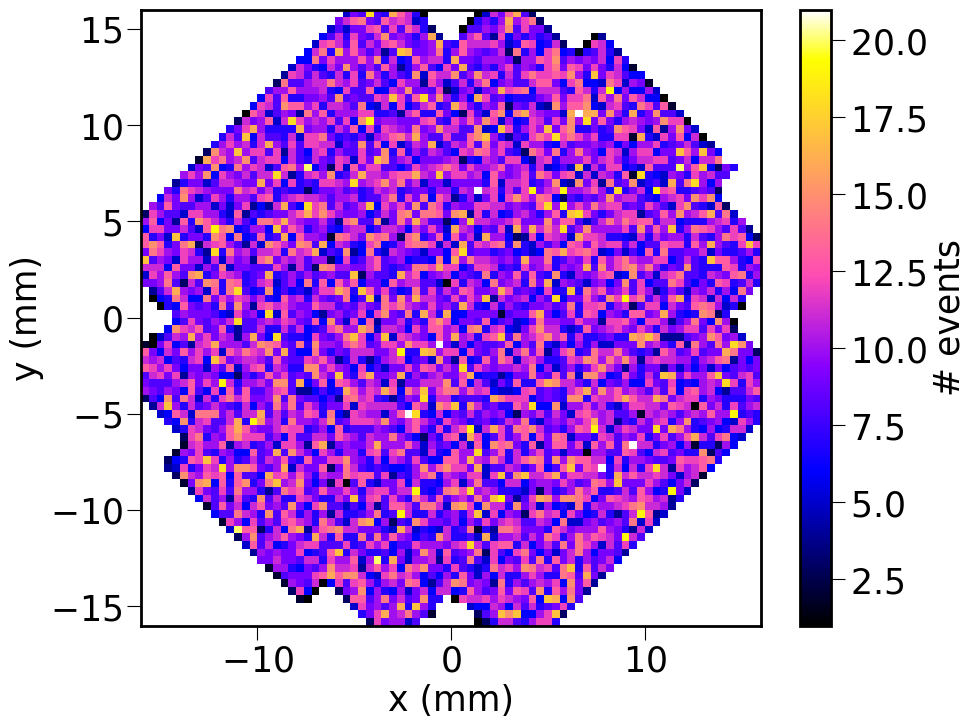

In [25]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

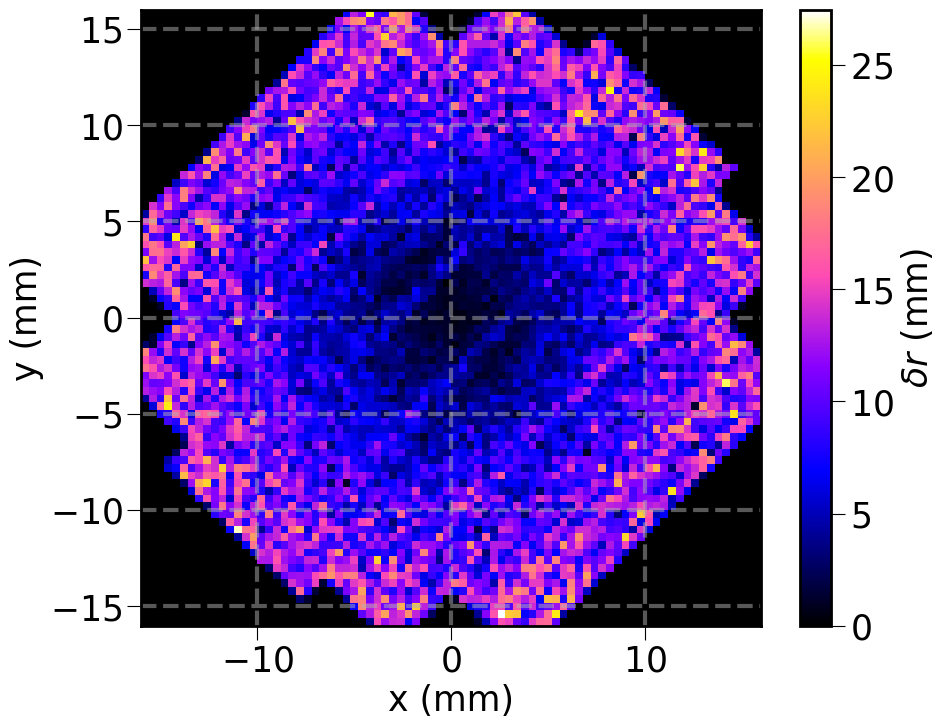

In [26]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

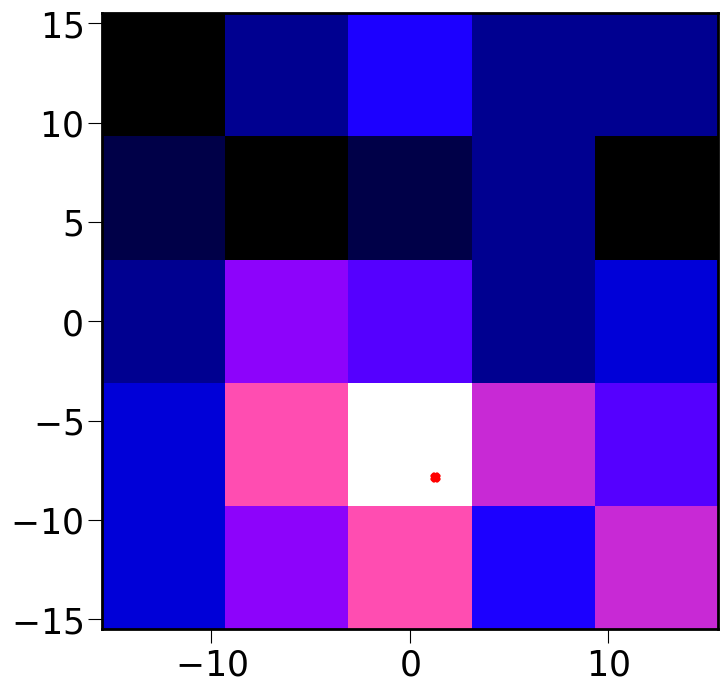

In [30]:
row = testdf.iloc[13]
img = row.image[0]
x   = row.x0
y   = row.y0
plt.imshow(img.T, origin="lower", extent=extent());
plt.scatter([x], [y], s=20, marker="X", color="r");

# NN

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

In [80]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [44]:
train     = pd.concat([read_file(filename) for filename in filenames[:10]])
test      = pd.concat([read_file(filename) for filename in filenames[10:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [81]:
model     = Linear(nsipms, nsipms)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [82]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.41 s/item | ETA 0.0 min | Ellapsed 3.4 min


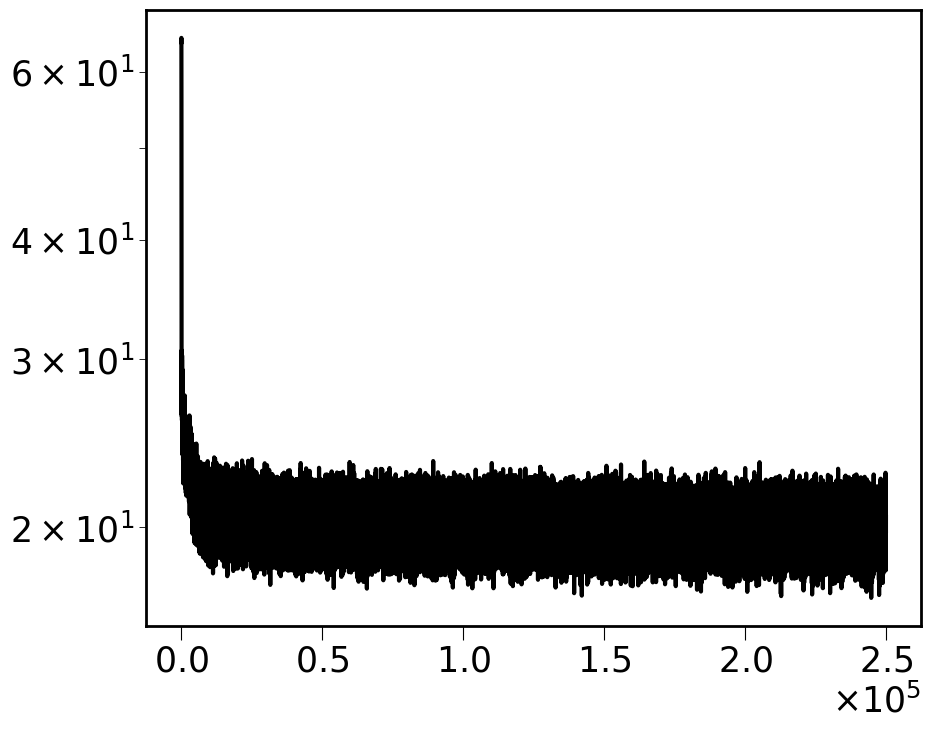

In [83]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [84]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

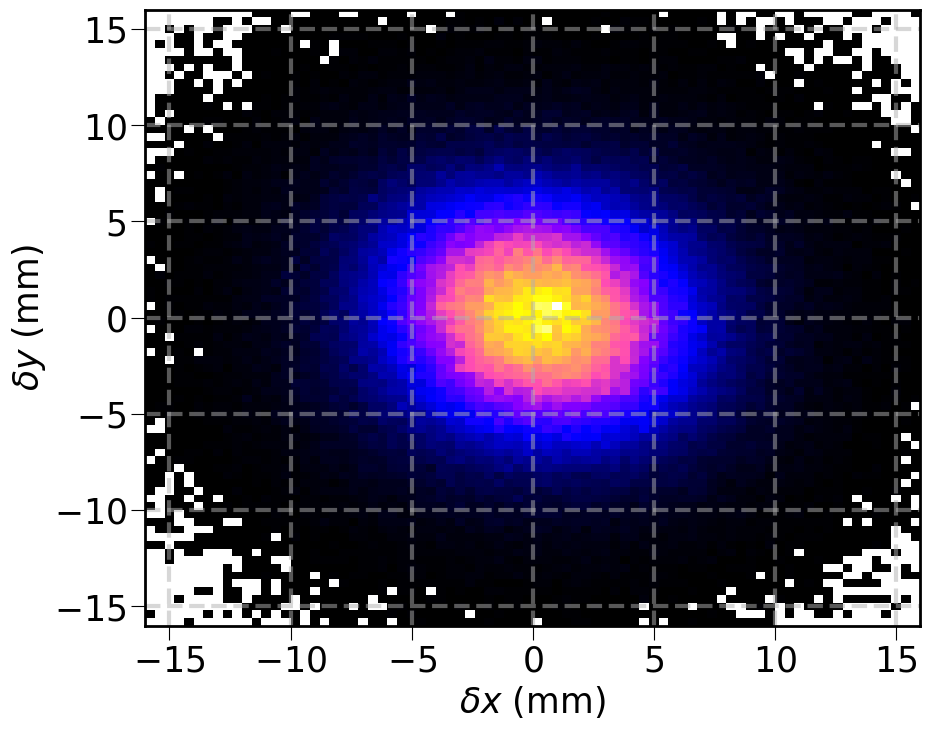

In [85]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

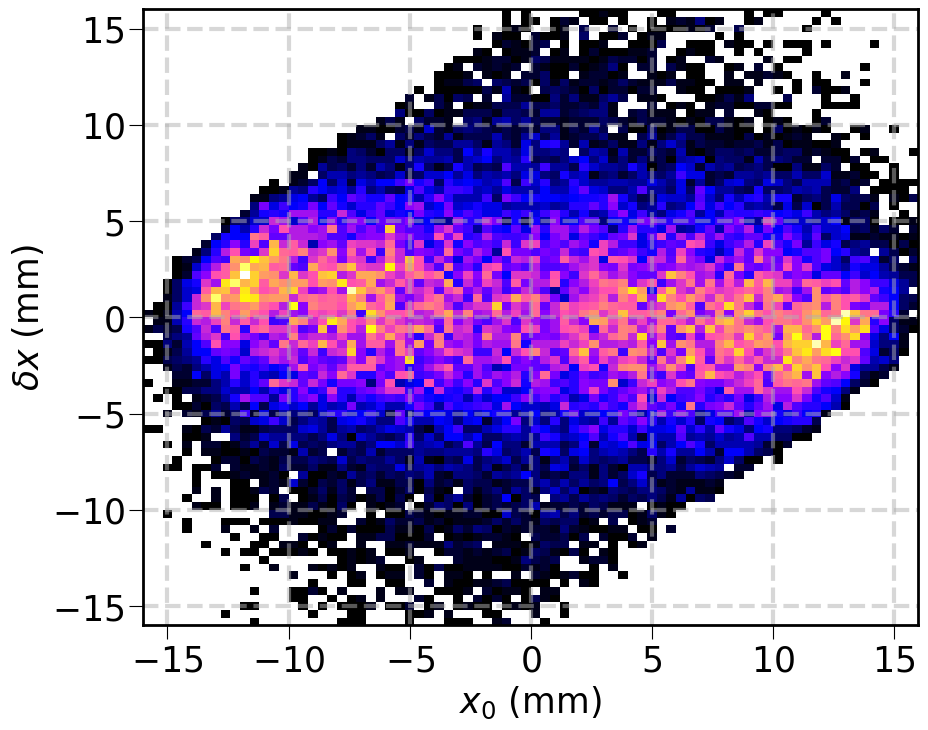

In [119]:
df = reco_nn
df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_0$ (mm)")
plt.ylabel("$\delta x$ (mm)")
plt.grid()

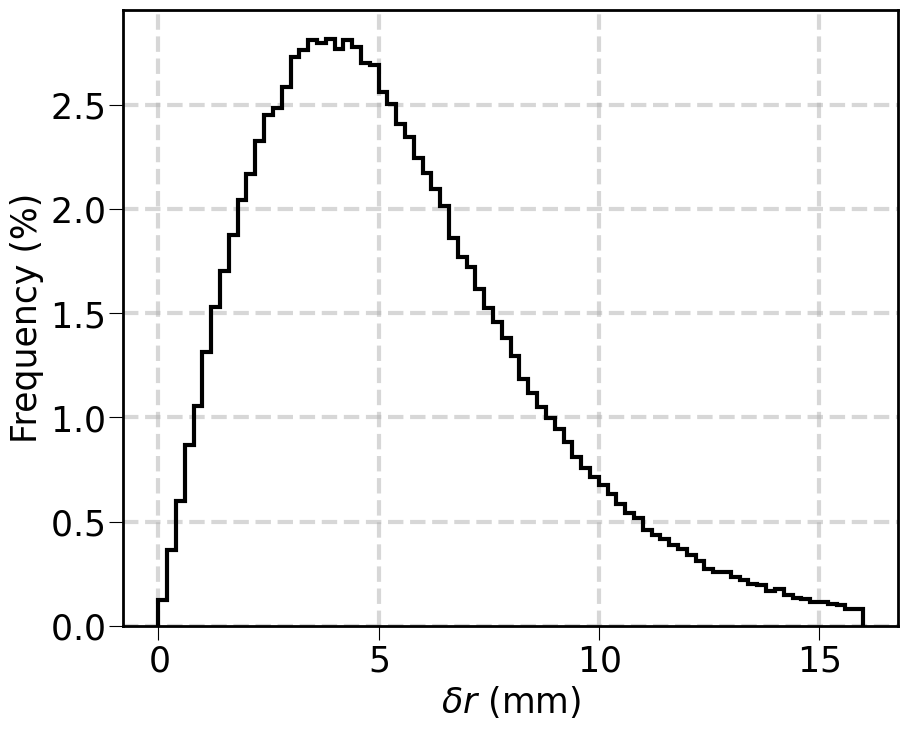

In [86]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

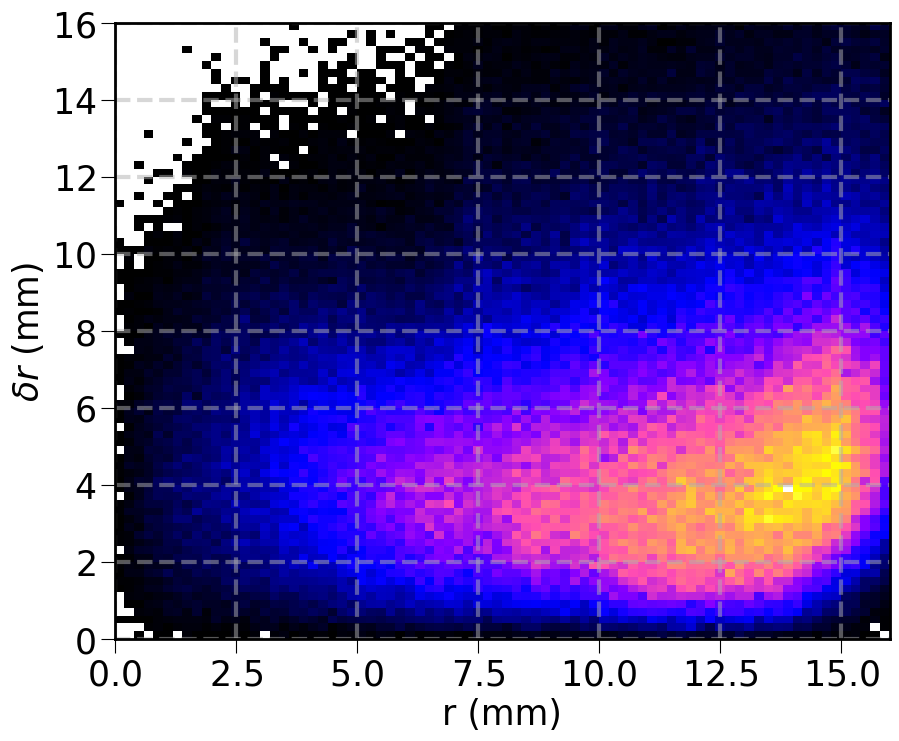

In [87]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

In [121]:
reco_bins  = np.arange(-16, 17.)
reco_error = (reco_nn.loc[lambda df: df.y.abs()<1]
                     .assign(rbin=lambda df: np.digitize(df.x, reco_bins))
                     .groupby("rbin")
                     .agg(r     = ("x", "mean"),
                          lower = ("dx", lambda x: np.percentile(x,  2.5)),
                          upper = ("dx", lambda x: np.percentile(x, 97.5)),
#                          lower = ("dx", lambda x: np.percentile(x, 15.86)),
#                          upper = ("dx", lambda x: np.percentile(x, 84.13)),
                         ))
reco_error.values

array([[-17.1391518 ,  -1.26121149,  -1.26121149],
       [-15.32894212,  -6.59165412,   0.61582845],
       [-14.36728003,  -6.93993912,   2.47597324],
       [-13.44477218,  -6.77894649,   3.31620142],
       [-12.47527802,  -6.71056738,   4.26918414],
       [-11.47804947,  -7.7551472 ,   5.12860654],
       [-10.49651759,  -8.89241744,   5.72974133],
       [ -9.50458481,  -9.33143488,   6.268997  ],
       [ -8.4870552 ,  -9.09882864,   7.07604927],
       [ -7.49695373,  -9.94859331,   7.54087881],
       [ -6.50115987,  -9.33739849,   7.88183468],
       [ -5.50625221, -10.59292632,   8.62964841],
       [ -4.5043262 , -11.51443223,   9.16722756],
       [ -3.50226384, -11.85393341,   9.47917867],
       [ -2.50537871, -11.6466235 ,  10.47832648],
       [ -1.49440536, -12.34074817,  11.30598277],
       [ -0.50103838, -10.97320098,  11.77353615],
       [  0.49385115, -12.14207801,  12.37786152],
       [  1.49659087, -10.66105777,  11.58471799],
       [  2.49186029,  -9.55019

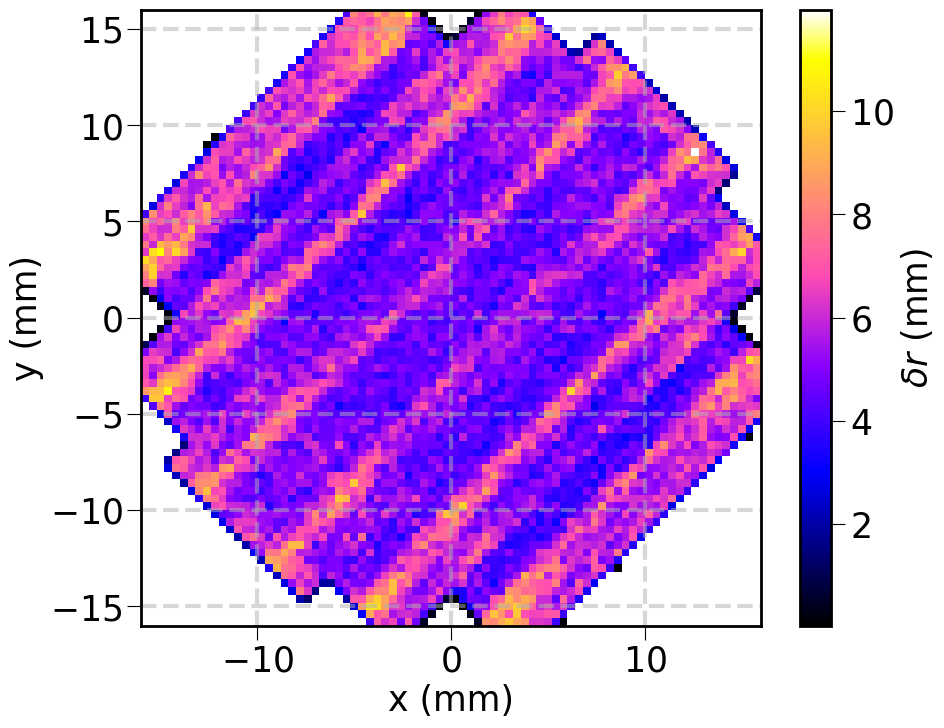

In [77]:
evt_per_bin = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
evt_per_bin = evt_per_bin[evt_per_bin>0].mean()
plt.hist2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr/evt_per_bin, cmin=1e-3)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

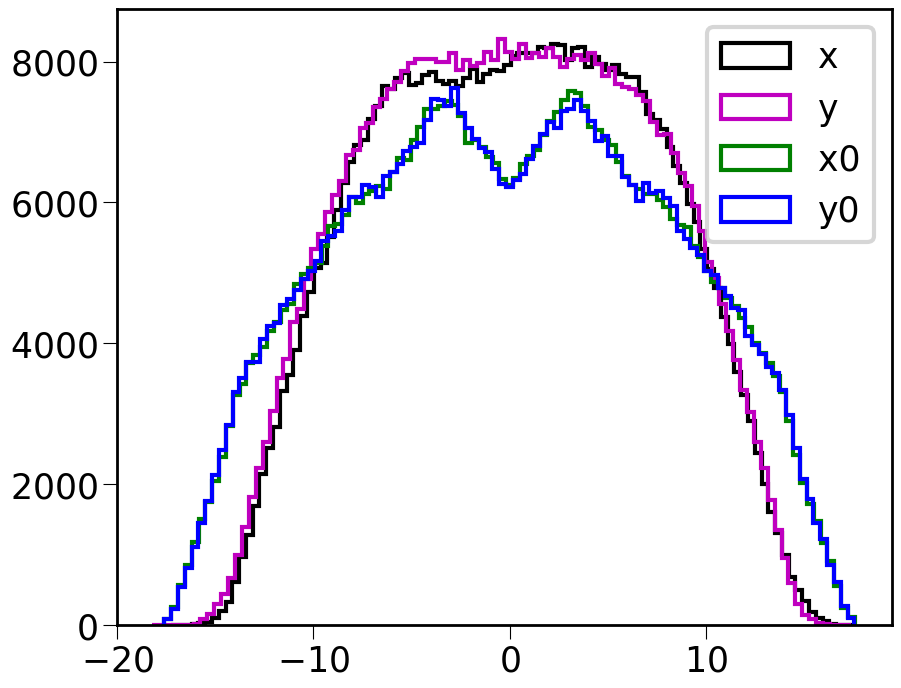

In [88]:
plt.hist(reco_nn.x , 101, histtype="step", label="x");
plt.hist(reco_nn.y , 101, histtype="step", label="y");
plt.hist(reco_nn.x0, 101, histtype="step", label="x0");
plt.hist(reco_nn.y0, 101, histtype="step", label="y0");
plt.legend()

In [43]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,3.350484,-16.557381,16.892975,-4.545127,-9.834334,-7.895611,6.723047,10.370151
1,-6.989807,5.016038,8.603374,-8.828445,-4.708154,-1.838638,-9.724193,9.896490
2,0.537810,5.610116,5.635835,0.629506,2.111025,0.091696,-3.499090,3.500291
3,-5.311894,0.469804,5.332629,-1.799546,-8.948701,3.512347,-9.418505,10.052106
4,1.651879,8.406141,8.566908,-0.204079,4.340308,-1.855958,-4.065833,4.469404
...,...,...,...,...,...,...,...,...
49995,8.661054,-5.369127,10.190259,8.544647,-1.408397,-0.116408,3.960730,3.962440
49996,-16.409254,-2.544477,16.605360,-11.666806,0.035356,4.742448,2.579833,5.398736
49997,13.142651,4.246746,13.811738,12.551658,4.550850,-0.590993,0.304104,0.664644


In [ ]:
reco = pd.DataFrame.join( reco_bb
                        , reco_nn.drop(columns="x0 y0 r0".split())
                        , lsuffix="_bb"
                        , rsuffix="_nn")

In [ ]:
reco

In [ ]:
reco.to_hdf(output, key="/data", complib="zlib", complevel=4)

In [ ]:
normhist(reco.x0  , 101, histtype="step", label="x$_{true}$");
normhist(reco.y0  , 101, histtype="step", label="y$_{true}$");
normhist(reco.x_bb, 101, histtype="step", label="x$_{B}$");
normhist(reco.y_bb, 101, histtype="step", label="y$_{B}$");
normhist(reco.x_nn, 101, histtype="step", label="x$_{NN}$");
normhist(reco.y_nn, 101, histtype="step", label="y$_{NN}$");
plt.legend()
plt.xlabel("x,y (mm)")
plt.ylabel("Frequency (%)")
plt.grid()